# Team T Quantitative Trading Project Draft: LSTM Signal Framework

**Team Members and Student IDs**
- Madhav Fadadu — `madhavf`
- Vidhi Jain — `vidhi`
- Bailey Meche — `baileymeche`
- Utsav Thakur — `utsavthakur`
- Mohamed Zakaria — `mohzak`

## Project Motivation and Strategy Overview

Our objective is to construct a hypothesis-driven nonlinear forecasting framework grounded in economically interpretable firm-level signals. We study whether delayed interactions between accounting fundamentals and market prices contain short-horizon predictive structure that can be systematically exploited. 

The economic intuition is that new fundamental information is not always incorporated into prices instantly, especially in environments where heterogeneous investor attention and processing speeds lead to gradual information diffusion, and that the adjustment path can depend on prior firm state, recent returns, and cross-feature interactions. 

This motivates modeling returns as a sequence problem rather than a single-period regression where the effect of past information may evolve nonlinearly over time rather than decay at a fixed rate. Classical linear lag structures provide useful baseline intuition, but they impose fixed additive effects and can miss regime-dependent responses. We therefore use an LSTM-based formulation to represent nonlinear, state-dependent lag dynamics while preserving a transparent feature pipeline. The gating mechanism allows the model to dynamically weight historical information conditional on evolving state variables.

The predictive signal in this draft is the model-implied next-step return direction and magnitude from lagged firm-level features and beta-adjusted price context.  At strategy level, the signal maps to relative long/short conviction scores after ranking predicted return strength across the fixed universe. 

The high-level trading intuition is that firms with stronger positive predicted drift receive higher weight, while weaker predicted drift receives lower or negative weight, subject to future risk constraints in the final project stage.

In this draft, we define the predictive target at the daily sampling frequency. However, event-time diagnostics suggest that return responses may persist across multi-week windows. The modeling framework is therefore designed to remain agnostic to horizon choice and can be extended to multi-step or cumulative return targets in the final stage.


### Survey-Based Illustration of Information Processing Dispersion

To complement our economic motivation, we conducted a short survey exploring how individuals process new firm-level information. The responses indicate substantial heterogeneity in attention, interpretation speed, and signal weighting. Only 13% of respondents report reading full earnings releases, while the majority rely on headlines or delayed summaries, suggesting variation in information acquisition speed.

Perceived incorporation horizons are broadly distributed across minutes, days, and weeks, with no consensus on when prices fully adjust. Responses to conflicting signals (e.g., strong fundamentals following weak price performance) are nearly evenly split across reliance on fundamentals, price trends, or delayed reaction. Additionally, over 80% of respondents believe identical earnings information may be interpreted differently by different investors.

While illustrative rather than definitive, these results are consistent with heterogeneous processing speeds and state-dependent weighting of signals. Such dispersion motivates modeling returns as a nonlinear sequence problem rather than imposing fixed-lag or static linear structures.

<div style="max-width:1100px;margin:0 auto;display:grid;grid-template-columns:repeat(3,minmax(0,1fr));gap:8px;">
  <a href="../images/q1.png" target="_blank" rel="noopener noreferrer">
    <img src="../images/q1.png" alt="q1" style="width:100%;aspect-ratio:4/3;object-fit:cover;display:block;border-radius:10px;cursor:zoom-in;">
  </a>
  <a href="../images/q2.png" target="_blank" rel="noopener noreferrer">
    <img src="../images/q2.png" alt="q2" style="width:100%;aspect-ratio:4/3;object-fit:cover;display:block;border-radius:10px;cursor:zoom-in;">
  </a>
  <a href="../images/q3.png" target="_blank" rel="noopener noreferrer">
    <img src="../images/q3.png" alt="q3" style="width:100%;aspect-ratio:4/3;object-fit:cover;display:block;border-radius:10px;cursor:zoom-in;">
  </a>
  <a href="../images/q4.png" target="_blank" rel="noopener noreferrer">
    <img src="../images/q4.png" alt="q4" style="width:100%;aspect-ratio:4/3;object-fit:cover;display:block;border-radius:10px;cursor:zoom-in;">
  </a>
  <a href="../images/q5.png" target="_blank" rel="noopener noreferrer">
    <img src="../images/q5.png" alt="q5" style="width:100%;aspect-ratio:4/3;object-fit:cover;display:block;border-radius:10px;cursor:zoom-in;">
  </a>
</div>


## Data Sources and Construction

This notebook uses Nasdaq Data Link fundamentals and a course-provided daily prices file. From Nasdaq Data Link, we pull `ZACKS/MT` (`ticker`, `sp500_member_flag`) and `ZACKS/MKTV` (`ticker`, `per_end_date`, `per_type`, `mkt_val`) to construct a deterministic top-10 static universe using market value on a fixed rank date. We also pull `ZACKS/FR` (`tot_debt_tot_equity`, `ret_equity`, `profit_margin`, `book_val_per_share`) and `ZACKS/FC` (`diluted_net_eps`) for quarterly fundamentals. The analysis range is 2006-01-01 through 2013-12-31, with quarterly accounting variables forward-shifted by 45 calendar days relative to period end to approximate reporting availability and avoid look-ahead bias.

The prices file must be placed at `data/PRICES.csv` and is treated as required draft input from the course website. This file contains daily ticker-level prices and volume fields used to construct adjusted returns, rolling beta, and event-time diagnostics. Preprocessing steps include ticker normalization for join consistency, date parsing, split-consistent intraday adjustments, and filtering to the fixed universe plus SPY. The resulting panel is arranged as a daily, point-in-time-safe feature table with train/dev/test labels.


### Data Window Selection: 2006–2013

We restrict the analysis to the 2006–2013 period to preserve a fully specified, closed evaluation framework with pre-defined train (2006–2011), development (2012), and test (2013) splits. Fixing the sample, universe definition, and feature construction rules in advance avoids implicit re-tuning based on later regimes and ensures strict out-of-sample testing. The window spans materially different market environments, including the 2008–2009 financial crisis, providing regime variation without expanding the model specification midstream. Our objective is methodological clarity and point-in-time integrity rather than recency. Extending the frozen specification to post-2013 years would be a separate out-of-sample robustness exercise and is outside the scope of this project.

## Data Cleaning and Formatting

The raw datasets require alignment and transformation before they can be used for modeling. We first standardize ticker identifiers across sources to ensure consistent joins. Quarterly accounting variables are forward-shifted by a fixed 45-day lag relative to fiscal period end to approximate reporting availability and preserve point-in-time integrity. Daily price data are parsed, filtered to the fixed universe plus SPY, and used to construct split-adjusted close-to-close returns and rolling market exposure measures.

We then perform an as-of merge between daily prices and lagged fundamentals to ensure that only information available at each date enters the feature set. This produces a daily cross-sectional panel indexed by ticker and date. Finally, we assign deterministic train, development, and test splits based strictly on calendar boundaries to maintain clean out-of-sample evaluation structure.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure project-root imports when running notebook from notebooks/.
CWD = Path.cwd().resolve()
if (CWD / "team_t").exists():
    TEAM_ROOT = CWD / "team_t"
elif CWD.name == "team_t":
    TEAM_ROOT = CWD
elif CWD.name == "notebooks" and CWD.parent.name == "team_t":
    TEAM_ROOT = CWD.parent
else:
    TEAM_ROOT = next((p for p in [CWD, *CWD.parents] if p.name == "team_t"), None)

if TEAM_ROOT is None:
    raise FileNotFoundError("Could not resolve team_t directory from current working directory")

if str(TEAM_ROOT) not in sys.path:
    sys.path.insert(0, str(TEAM_ROOT))

from src.data_utils import (
    configure_api_from_env,
    fetch_zacks_table,
    load_prices_csv_required,
    build_static_top10_universe,
    prepare_fundamentals_with_availability,
    asof_join_point_in_time,
    validate_point_in_time_panel,
)
from src.feature_engineering import (
    add_split_adjusted_intraday_prices,
    compute_price_to_book,
    compute_rolling_beta_vs_spy,
    assign_time_split,
    build_lstm_tensors,
    compute_event_intensity_diagnostics,
)


The code below runs the end-to-end draft data pipeline: API configuration, universe construction, required prices loading, point-in-time fundamental merge, and feature assembly. Validation checks are embedded in utility functions so the notebook remains readable and high-level.

In [6]:
# Parameters (single source of defaults)
PRICE_START = pd.Timestamp("2006-01-01")
PRICE_END = pd.Timestamp("2013-12-31")
RANK_DATE = pd.Timestamp("2012-12-31")
LAG_DAYS = 45
LOOKBACK = 20
BETA_WINDOW = 252
BETA_MIN_OBS = 126

TRAIN_START = pd.Timestamp("2006-01-01")
TRAIN_END = pd.Timestamp("2011-12-31")
DEV_START = pd.Timestamp("2012-01-01")
DEV_END = pd.Timestamp("2012-12-31")
TEST_START = pd.Timestamp("2013-01-01")
TEST_END = pd.Timestamp("2013-12-31")

PRICES_CSV = TEAM_ROOT / "data" / "PRICES.csv"
OUTPUT_DIR = TEAM_ROOT / "data" / "lstm_draft" / "processed"
FIG_DIR = TEAM_ROOT / "docs" / "figures"

for path in [OUTPUT_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)


In [7]:
# Configure API credentials only (no data fetch side effects).
env_candidates = [
    TEAM_ROOT / ".env",
    TEAM_ROOT.parent / ".env",
    Path.cwd() / ".env",
]
configure_api_from_env(env_candidates)


In [9]:
# 1) Universe and data loading
mt_cols = ["ticker", "sp500_member_flag"]
mktv_cols = ["ticker", "per_end_date", "per_type", "mkt_val"]
fr_cols = [
    "ticker", "per_end_date", "per_type",
    "tot_debt_tot_equity", "ret_equity", "profit_margin", "book_val_per_share",
]
fc_cols = ["ticker", "per_end_date", "per_type", "diluted_net_eps"]
price_cols = ["ticker", "date", "open", "close", "adj_close", "volume"]

mt = fetch_zacks_table("ZACKS/MT", mt_cols, filters={"sp500_member_flag": "Y"}, paginate=True)
mktv = fetch_zacks_table("ZACKS/MKTV", mktv_cols, filters={"per_end_date": str(RANK_DATE.date())}, paginate=True)

top10 = build_static_top10_universe(mt_df=mt, mktv_df=mktv, rank_date=str(RANK_DATE.date()))
static_tickers = top10["ticker_price"].tolist()
price_tickers = sorted(set(static_tickers + ["SPY"]))
raw_tickers = sorted(top10["ticker"].tolist())

prices = load_prices_csv_required(
    csv_path=PRICES_CSV,
    tickers=price_tickers,
    start=str(PRICE_START.date()),
    end=str(PRICE_END.date()),
    usecols=price_cols,
)
prices_adj = add_split_adjusted_intraday_prices(prices)

fr = fetch_zacks_table(
    "ZACKS/FR",
    fr_cols,
    filters={"ticker": {"in": raw_tickers}, "per_end_date": {"between": ("2006-01-01", "2013-12-31")}},
    paginate=True,
)
fc = fetch_zacks_table(
    "ZACKS/FC",
    fc_cols,
    filters={"ticker": {"in": raw_tickers}, "per_end_date": {"between": ("2006-01-01", "2013-12-31")}},
    paginate=True,
)
fundamentals = prepare_fundamentals_with_availability(fr, fc, lag_days=LAG_DAYS)

# 2) Point-in-time merge and feature construction
fund_pti = fundamentals.copy()
fund_pti["ticker"] = fund_pti["ticker_price"]
prices_model = prices_adj[prices_adj["ticker"].isin(static_tickers)].copy()

panel = asof_join_point_in_time(
    prices_df=prices_model,
    fundamentals_df=fund_pti,
    on_date_col="date",
    by_ticker_col="ticker",
)
validate_point_in_time_panel(panel)

panel = compute_price_to_book(panel)
beta_df = compute_rolling_beta_vs_spy(
    prices_df=prices_adj[["ticker", "date", "adj_close"]].copy(),
    window=BETA_WINDOW,
    min_obs=BETA_MIN_OBS,
)
panel = panel.merge(beta_df, on=["ticker", "date"], how="left")
panel = assign_time_split(panel, TRAIN_START, TRAIN_END, DEV_START, DEV_END, TEST_START, TEST_END)

panel["adj_close"] = pd.to_numeric(panel["adj_close"], errors="coerce")
panel.loc[panel["adj_close"] <= 0, "adj_close"] = np.nan
panel["log_ret"] = panel.groupby("ticker")["adj_close"].transform(lambda s: np.log(s).diff())
panel["target_next_log_ret"] = panel.groupby("ticker")["log_ret"].shift(-1)

panel = panel[(panel["date"] >= PRICE_START) & (panel["date"] <= PRICE_END)].copy()
panel = panel.sort_values(["ticker", "date"]).reset_index(drop=True)


## Options Data: OptionMetrics (Ivy DB)

We extend the data pipeline with equity options data from **OptionMetrics (Ivy DB)** on WRDS. This serves two purposes:

1. **Universe expansion:** Each distinct strike × expiry × type contract counts as a separate asset, making it straightforward to hold 5+ simultaneous positions even on a small underlying universe.
2. **Non-standard information:** Implied volatility (IV) is a forward-looking, market-derived signal — distinct from price, HLOC, and volume — and complements backward-looking accounting fundamentals.

We pull near-ATM, ~30-day tenor contracts for our 10 underlying tickers over the same 2006–2013 window. IV values are sourced directly from OptionMetrics (not self-computed) to avoid Black-Scholes inversion errors.

**Point-in-time safety:** Options prices are observed end-of-day; no forward-shift is needed (unlike quarterly fundamentals). We use the daily mid-price `(best_bid + best_offer) / 2` for signal construction and bid/ask for realistic fill simulation at the backtest stage.

### WRDS Connection Note

The block below connects to WRDS via `wrds.Connection`. Credentials are read from environment variables `WRDS_USERNAME` and `WRDS_PASSWORD` (or the `~/.pgpass` file if configured). The connection is reused across all three OptionMetrics queries.

If your institution uses `optionm_all` (the extended schema available at most universities) rather than `optionm`, change the schema prefix in the SQL strings accordingly.

In [12]:
db = connect_wrds()
# Check actual columns in secnmd
cols = db.raw_sql("""
    SELECT column_name 
    FROM information_schema.columns 
    WHERE table_schema = 'optionm' 
    AND table_name = 'secnmd'
    ORDER BY ordinal_position
""")
print(cols)
db.close()

Loading library list...
Done
   column_name
0        secid
1  effect_date
2        cusip
3       ticker
4        class
5       issuer
6        issue
7          sic


In [20]:
import os
import pandas as pd
from src.wrds_utils import connect_wrds

db = connect_wrds()

OPT_START   = PRICE_START.strftime("%Y-%m-%d")
OPT_END     = PRICE_END.strftime("%Y-%m-%d")
TICKERS_SQL = ", ".join(f"'{t}'" for t in raw_tickers)

try:
    # ── Step 1: Resolve secid for our tickers ─────────────────────────────────
    secnmd = db.raw_sql(f"""
        SELECT secid, ticker, effect_date
        FROM optionm.secnmd
        WHERE ticker IN ({TICKERS_SQL})
        ORDER BY ticker, effect_date
    """)

    secnmd["effect_date"] = pd.to_datetime(secnmd["effect_date"])

    # One secid per ticker — take earliest record (secid is stable across updates)
    secnmd = secnmd.drop_duplicates("ticker", keep="first")

    secid_list = secnmd["secid"].unique().tolist()
    if not secid_list:
        raise ValueError(
            f"No secids found in optionm.secnmd for tickers: {raw_tickers}\n"
            "Check that these tickers exist in OptionMetrics."
        )

    SECIDS_SQL = ", ".join(str(s) for s in secid_list)
    print(f"[secnmd] resolved {len(secid_list)} secids for {secnmd['ticker'].nunique()} tickers")
    print(secnmd[["ticker", "secid"]].to_string(index=False))

    # ── Step 2: Pull near-ATM ~30-day options (year-partitioned tables) ────────
    opt_chunks = []
    for year in range(2006, 2014):
        print(f"  Pulling {year}...", end=" ")
        try:
            chunk = db.raw_sql(f"""
                SELECT
                    o.secid,
                    o.date,
                    o.exdate,
                    o.cp_flag,
                    o.strike_price,
                    o.best_bid,
                    o.best_offer,
                    (o.best_bid + o.best_offer) / 2.0  AS mid_price,
                    o.impl_volatility,
                    o.delta,
                    o.gamma,
                    o.vega,
                    o.volume,
                    o.open_interest
                FROM optionm.opprcd{year} o
                WHERE o.secid IN ({SECIDS_SQL})
                  AND o.best_bid        > 0
                  AND o.impl_volatility IS NOT NULL
                  AND o.volume          > 0
                  AND ABS(o.delta)      BETWEEN 0.40 AND 0.60
                  AND (o.exdate - o.date) BETWEEN 20 AND 60
            """)
            print(f"{len(chunk):,} rows")
            opt_chunks.append(chunk)
        except Exception as e:
            print(f"SKIPPED ({e})")

    if not opt_chunks:
        raise ValueError("No options data returned for any year. Check WRDS subscription.")

    opt_raw = pd.concat(opt_chunks, ignore_index=True)
    opt_raw["date"]   = pd.to_datetime(opt_raw["date"])
    opt_raw["exdate"] = pd.to_datetime(opt_raw["exdate"])

    opt_raw = opt_raw.merge(
        secnmd[["secid", "ticker"]].drop_duplicates("secid"),
        on="secid", how="left"
    )
    print(
        f"\n[opt_raw] rows={len(opt_raw):,}  tickers={opt_raw['ticker'].nunique()}  "
        f"date_min={opt_raw['date'].min().date()}  date_max={opt_raw['date'].max().date()}"
    )

    # ── Step 3: Pull zero curve ────────────────────────────────────────────────
    zero_curve = db.raw_sql(f"""
        SELECT date, days, rate
        FROM optionm.zerocd
        WHERE date BETWEEN '{OPT_START}' AND '{OPT_END}'
    """)
    zero_curve["date"] = pd.to_datetime(zero_curve["date"])
    print(
        f"[zero_curve] rows={len(zero_curve):,}  "
        f"date_min={zero_curve['date'].min().date()}  date_max={zero_curve['date'].max().date()}"
    )

except Exception as e:
    print(f"[ERROR] WRDS query failed: {e}")
    raise

finally:
    db.close()
    print("[db] WRDS connection closed")

Loading library list...
Done
[secnmd] resolved 9 secids for 9 tickers
ticker     secid
  AAPL  101594.0
   CVX  102968.0
    GE  105169.0
 GOOGL  121812.0
   IBM  106276.0
   JNJ  106566.0
  MSFT  107525.0
   WMT  111860.0
   XOM  104533.0
  Pulling 2006... 4,609 rows
  Pulling 2007... 5,197 rows
  Pulling 2008... 8,476 rows
  Pulling 2009... 6,521 rows
  Pulling 2010... 5,862 rows
  Pulling 2011... 9,915 rows
  Pulling 2012... 11,821 rows
  Pulling 2013... 19,761 rows

[opt_raw] rows=72,162  tickers=9  date_min=2006-01-03  date_max=2013-12-31
[zero_curve] rows=92,299  date_min=2006-01-03  date_max=2013-12-31
[db] WRDS connection closed


### ATM Implied Volatility Feature: Daily Front-Month IV per Ticker

From the raw options panel we construct a single daily ATM IV series per underlying by averaging `impl_volatility` across near-ATM calls and puts within the 30-day tenor bucket. This collapses the multi-contract panel to one IV observation per (ticker, date), which is then joined to the main equity panel as a 10th input feature.

This corresponds to **Option A** from our integration plan: IV as an additional LSTM input. The full multi-contract panel (`opt_raw`) is retained for backtest-stage **Option B** (trade individual contracts) and **Option C** (vol risk premium straddle signal).

In [24]:
# Pipeline Summary: initial code checkpoints for obtain/clean/arrange evidence

def _summary(tag: str, df: pd.DataFrame, ticker_col: str = "ticker", date_col: str = "date") -> None:
    date_min = pd.to_datetime(df[date_col], errors="coerce").min() if date_col in df.columns else None
    date_max = pd.to_datetime(df[date_col], errors="coerce").max() if date_col in df.columns else None
    tickers = int(df[ticker_col].nunique()) if ticker_col in df.columns else None
    print(f"[{tag}] rows={len(df):,} tickers={tickers} date_min={date_min} date_max={date_max}")

_summary("after loading prices", prices_adj)
_summary("after loading fundamentals", fundamentals, ticker_col="ticker_price", date_col="feature_available_date")
_summary("after point-in-time join", panel)

feature_cols_for_model = [
    "adj_close", "volume", "tot_debt_tot_equity", "ret_equity",
    "profit_margin", "book_val_per_share", "diluted_net_eps", "price_to_book", "beta_252d",
]
available_features = [c for c in feature_cols_for_model if c in panel.columns]
print(f"[after feature build] available_feature_count={len(available_features)} features={available_features}")
print(f"[before tensor build] target_non_null={int(panel['target_next_log_ret'].notna().sum()):,}")

[after loading prices] rows=22,143 tickers=11 date_min=2006-01-03 00:00:00 date_max=2013-12-31 00:00:00
[after loading fundamentals] rows=320 tickers=10 date_min=2006-03-17 00:00:00 date_max=2014-02-14 00:00:00
[after point-in-time join] rows=20,130 tickers=10 date_min=2006-01-03 00:00:00 date_max=2013-12-31 00:00:00
[after feature build] available_feature_count=9 features=['adj_close', 'volume', 'tot_debt_tot_equity', 'ret_equity', 'profit_margin', 'book_val_per_share', 'diluted_net_eps', 'price_to_book', 'beta_252d']
[before tensor build] target_non_null=20,120


In [25]:
# Daily ATM IV feature
atm_iv = (
    opt_raw
    .groupby(["ticker", "date"])["impl_volatility"]
    .mean()
    .reset_index()
    .rename(columns={"impl_volatility": "atm_iv_30d"})
)

panel_with_opts = panel.merge(atm_iv, on=["ticker", "date"], how="left")

panel_with_opts["atm_iv_30d"] = (
    panel_with_opts
    .sort_values(["ticker", "date"])
    .groupby("ticker")["atm_iv_30d"]
    .transform(lambda s: s.ffill())
)

_summary("panel_with_opts (after IV join)", panel_with_opts)
miss_iv = panel_with_opts["atm_iv_30d"].isna().mean()
print(f"[atm_iv_30d] missing fraction after ffill: {miss_iv:.3f}")


[panel_with_opts (after IV join)] rows=20,130 tickers=10 date_min=2006-01-03 00:00:00 date_max=2013-12-31 00:00:00
[atm_iv_30d] missing fraction after ffill: 0.101


### Options Export and Updated Feature List

The raw options panel and augmented equity panel are written to the same output directory as the equity artifacts. The updated `model_feature_cols_with_iv` list includes `atm_iv_30d` as the 10th feature; this replaces `model_feature_cols` when passing to `build_lstm_tensors` in the modeling section.

In [26]:
opt_csv = OUTPUT_DIR / "options_panel_2006_2013.csv"
opt_raw.to_csv(opt_csv, index=False)

try:
    opt_parquet = OUTPUT_DIR / "options_panel_2006_2013.parquet"
    opt_raw.to_parquet(opt_parquet, index=False)
except Exception:
    pass

panel_opts_csv = OUTPUT_DIR / "lstm_feature_panel_with_iv_2006_2013.csv"
panel_with_opts.to_csv(panel_opts_csv, index=False)

model_feature_cols_with_iv = [
    "adj_close", "volume",
    "tot_debt_tot_equity", "ret_equity", "profit_margin",
    "book_val_per_share", "diluted_net_eps", "price_to_book",
    "beta_252d",
    "atm_iv_30d",
]
model_feature_cols_with_iv = [
    c for c in model_feature_cols_with_iv if c in panel_with_opts.columns
]
print(f"Updated feature count: {len(model_feature_cols_with_iv)}")
print(f"Features: {model_feature_cols_with_iv}")

n_contracts = (
    opt_raw
    .groupby(["ticker", "date"])
    .apply(lambda g: g[["strike_price", "exdate", "cp_flag"]].drop_duplicates().shape[0])
    .reset_index(name="n_contracts")
)
avg_daily = n_contracts.groupby("ticker")["n_contracts"].mean().round(1)
print("\nAverage daily distinct option contracts per ticker:")
print(avg_daily.to_string())
total_avg = n_contracts.groupby("date")["n_contracts"].sum().mean()
print(f"\nAvg total distinct option assets across all tickers on a trading day: {total_avg:.0f}")


Updated feature count: 10
Features: ['adj_close', 'volume', 'tot_debt_tot_equity', 'ret_equity', 'profit_margin', 'book_val_per_share', 'diluted_net_eps', 'price_to_book', 'beta_252d', 'atm_iv_30d']

Average daily distinct option contracts per ticker:
ticker
AAPL      9.1
CVX       2.9
GE        2.8
GOOGL    11.3
IBM       3.1
JNJ       2.5
MSFT      3.2
WMT       2.6
XOM       2.7

Avg total distinct option assets across all tickers on a trading day: 36


C:\Users\vidhi\AppData\Local\Temp\ipykernel_50244\968487818.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[["strike_price", "exdate", "cp_flag"]].drop_duplicates().shape[0])


## Exploratory Data Visualization

The figures below are diagnostic visualizations used to understand feature behavior and timing structure before any model training. They are included to validate data readiness and to motivate the modeling specification.


### Figure 1: Top-10 Adjusted Price Paths (Normalized)

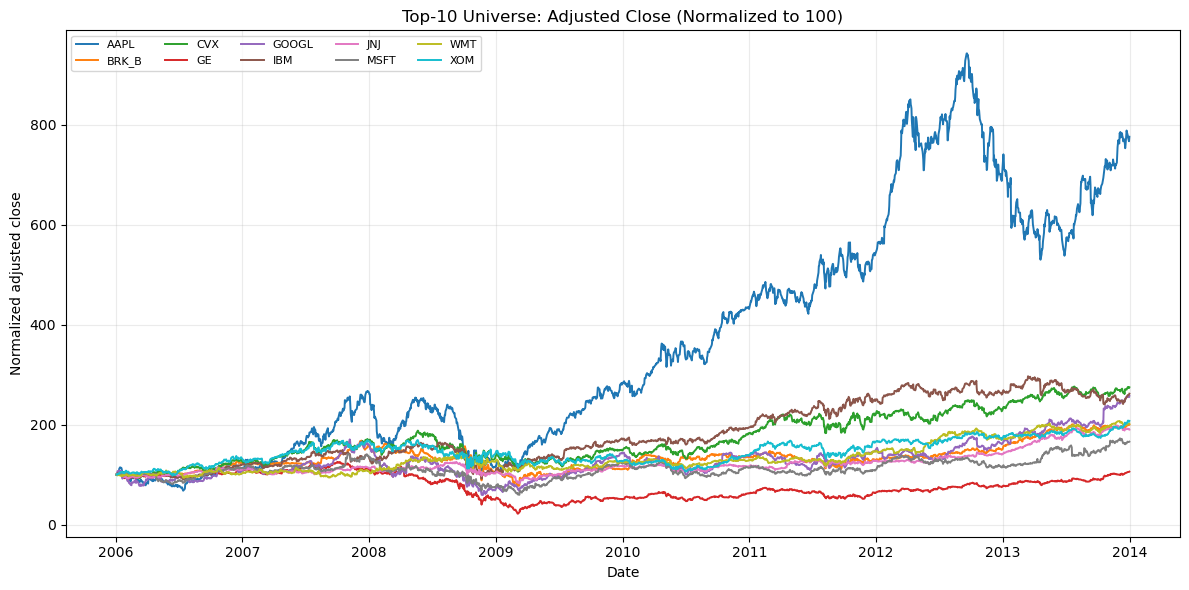

In [27]:
plot_df = panel[["ticker", "date", "adj_close"]].dropna().copy()
plot_df = plot_df.sort_values(["ticker", "date"])
plot_df["adj_close_norm100"] = plot_df.groupby("ticker")["adj_close"].transform(
    lambda s: 100 * s / s.iloc[0] if len(s) > 0 else np.nan
)

fig, ax = plt.subplots(figsize=(12, 6))
for ticker, g in plot_df.groupby("ticker"):
    ax.plot(g["date"], g["adj_close_norm100"], label=ticker, linewidth=1.4)

ax.set_title("Top-10 Universe: Adjusted Close (Normalized to 100)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized adjusted close")
ax.legend(ncol=5, fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()

fig1_path = FIG_DIR / "lstm_top10_adjusted_price_paths.png"
fig.savefig(fig1_path, dpi=140)
plt.show()


This figure shows normalized adjusted-close trajectories for the fixed top-10 universe over the draft sample. The normalization allows direct comparison of relative path behavior despite very different nominal price levels. Several names exhibit persistent trend phases while others show abrupt regime changes, indicating heterogeneous temporal structure within the same universe. The coexistence of momentum-like segments and reversals motivates a model that can adaptively condition on recent sequence state rather than rely on one static coefficient. Cross-ticker dispersion is also visible, which supports ranking-based signal design instead of absolute-level forecasting alone. As a diagnostic, this chart confirms that the panel contains rich time variation suitable for sequence modeling.


### Figure 2: Feature Missingness Heatmap

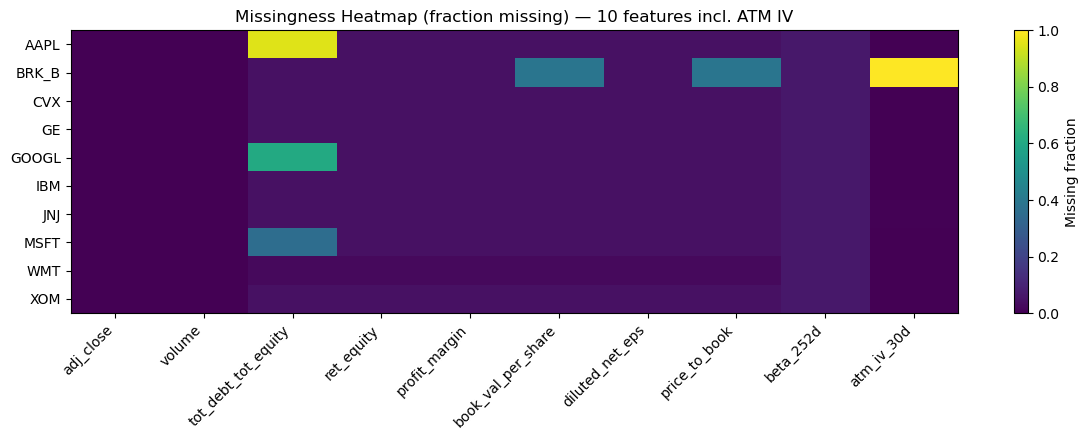

In [ ]:
# early-2006 options gaps are visible alongside the fundamental gaps.
missing_features = [
    "adj_close", "volume", "tot_debt_tot_equity", "ret_equity",
    "profit_margin", "book_val_per_share", "diluted_net_eps", "price_to_book",
    "beta_252d",
    "atm_iv_30d",           # <-- added: OptionMetrics front-month ATM IV
]

# Use panel_with_opts so atm_iv_30d is present
_heatmap_panel = panel_with_opts if "atm_iv_30d" in panel_with_opts.columns else panel
missing_features = [c for c in missing_features if c in _heatmap_panel.columns]

missing = _heatmap_panel.groupby("ticker")[missing_features].apply(lambda x: x.isna().mean())

fig, ax = plt.subplots(figsize=(12, 4.5))   # slightly wider to fit extra column
im = ax.imshow(missing.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(missing_features)))
ax.set_xticklabels(missing_features, rotation=45, ha="right")
ax.set_yticks(range(len(missing.index)))
ax.set_yticklabels(missing.index)
ax.set_title("Missingness Heatmap (fraction missing) — 10 features incl. ATM IV")
cb = fig.colorbar(im, ax=ax)
cb.set_label("Missing fraction")
fig.tight_layout()

fig2_path = FIG_DIR / "lstm_feature_missingness_heatmap.png"
fig.savefig(fig2_path, dpi=140)
plt.show()


This heatmap reports the fraction of missing observations for each feature by ticker. It makes explicit where data availability differs between price-derived and fundamental variables across the universe. Fundamental fields show structured missingness patterns consistent with quarterly reporting cadence and availability lags, while daily price variables are much denser. The beta feature has expected early-sample gaps due to rolling-window minimum-observation requirements. This diagnostic matters because sequence models are sensitive to missing-data handling and the effective information set over time. The chart supports the draft choice to keep the feature panel explicit and auditable before any model fitting.


### Figure 3: Forward-Fill and No-Lookahead Fundamental Alignment

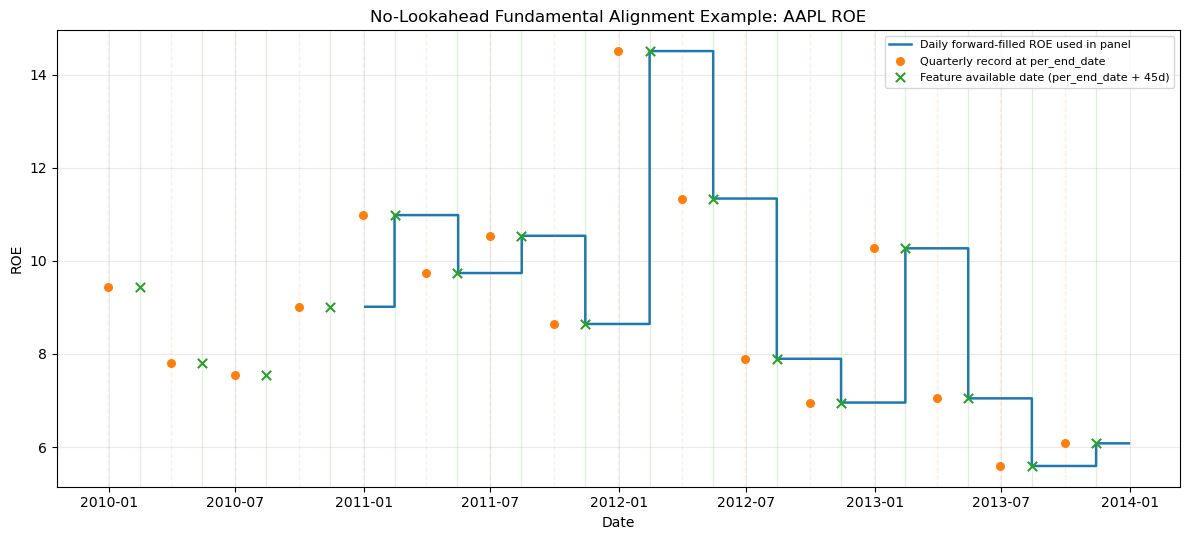

In [29]:
example_ticker = static_tickers[0]

daily_ex = panel[panel["ticker"] == example_ticker][["date", "ret_equity"]].copy()
daily_ex = daily_ex[(daily_ex["date"] >= "2011-01-01") & (daily_ex["date"] <= "2013-12-31")]

fund_ex = fundamentals[fundamentals["ticker_price"] == example_ticker][
    ["per_end_date", "feature_available_date", "ret_equity"]
].copy()
fund_ex = fund_ex[(fund_ex["feature_available_date"] >= "2010-01-01") & (fund_ex["feature_available_date"] <= "2013-12-31")]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(
    daily_ex["date"],
    daily_ex["ret_equity"],
    drawstyle="steps-post",
    color="tab:blue",
    linewidth=1.8,
    label="Daily forward-filled ROE used in panel",
)
ax.scatter(fund_ex["per_end_date"], fund_ex["ret_equity"], color="tab:orange", marker="o", s=30, label="Quarterly record at per_end_date", zorder=3)
ax.scatter(fund_ex["feature_available_date"], fund_ex["ret_equity"], color="tab:green", marker="x", s=45, label="Feature available date (per_end_date + 45d)", zorder=3)

for d in fund_ex["per_end_date"].dropna().unique():
    ax.axvline(pd.Timestamp(d), color="tab:orange", alpha=0.12, linestyle="--", linewidth=1)
for d in fund_ex["feature_available_date"].dropna().unique():
    ax.axvline(pd.Timestamp(d), color="tab:green", alpha=0.15, linestyle="-", linewidth=1)

ax.set_title(f"No-Lookahead Fundamental Alignment Example: {example_ticker} ROE")
ax.set_xlabel("Date")
ax.set_ylabel("ROE")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="best")
fig.tight_layout()

fig3_path = FIG_DIR / "lstm_forward_fill_no_lookahead_example.png"
fig.savefig(fig3_path, dpi=140)
plt.show()


This figure visualizes how quarterly fundamentals enter the daily panel only after the explicit availability lag. The stepwise daily line confirms that values are held constant between updates instead of being interpolated or backfilled across unavailable dates. Orange markers identify accounting period endpoints, while green markers show the first admissible daily join date under point-in-time rules. The gap between those markers is economically important because it prevents accidental lookahead leakage. This behavior directly affects signal timing and therefore model realism. As a draft diagnostic, the plot confirms that the data assembly process preserves causal ordering.


### Figure 4: Fundamental Timing vs Return Response

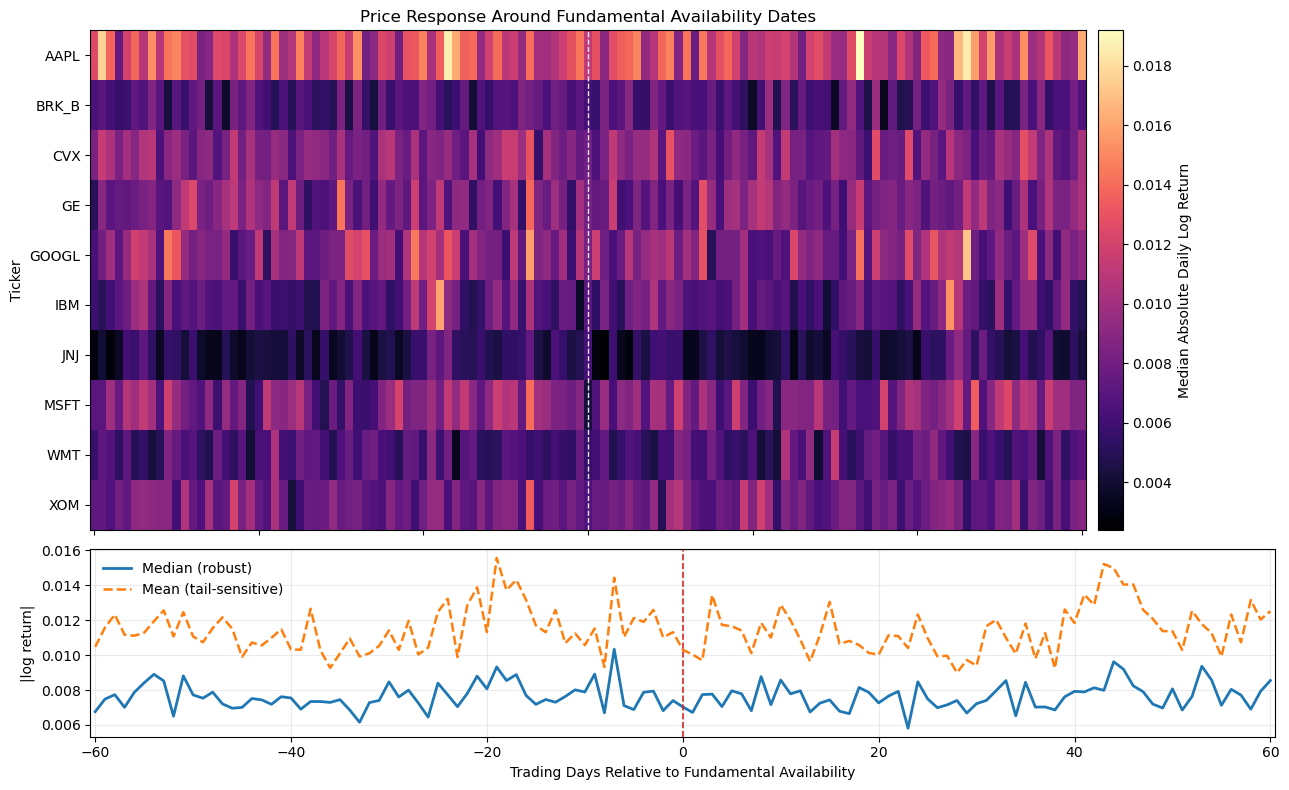

In [30]:
EVENT_WINDOW = 60
raw_diag = compute_event_intensity_diagnostics(
    mode="raw",
    prices_df=prices_adj,
    fundamentals_df=fundamentals,
    window=EVENT_WINDOW,
)

raw_heatmap = raw_diag["heatmap_df"]
raw_baseline_median = raw_diag["baseline_median"]
raw_baseline_mean = raw_diag["baseline_mean"]
raw_event_panel = raw_diag["event_panel_df"]

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 8),
    gridspec_kw={"height_ratios": [3.2, 1.2]},
    sharex=True,
)

im = ax1.imshow(
    raw_heatmap.values.astype(float),
    aspect="auto",
    cmap="magma",
    interpolation="nearest",
    extent=[-EVENT_WINDOW - 0.5, EVENT_WINDOW + 0.5, len(raw_heatmap.index) - 0.5, -0.5],
)
ax1.set_title(raw_diag["figure_title"])
ax1.set_ylabel("Ticker")
ax1.set_yticks(range(len(raw_heatmap.index)))
ax1.set_yticklabels(raw_heatmap.index.tolist())
ax1.axvline(0, color="white", linestyle="--", linewidth=1, alpha=0.9)
cb = fig.colorbar(im, ax=ax1, pad=0.01)
cb.set_label(raw_diag["colorbar_label"])

x = raw_baseline_median.index.values
ax2.plot(x, raw_baseline_median.values, color="tab:blue", linewidth=2, linestyle="-", label="Median (robust)")
ax2.plot(x, raw_baseline_mean.reindex(raw_baseline_median.index).values, color="tab:orange", linewidth=1.8, linestyle="--", label="Mean (tail-sensitive)")
ax2.axvline(0, color="tab:red", linestyle="--", linewidth=1.2)
ax2.set_xlabel("Trading Days Relative to Fundamental Availability")
ax2.set_ylabel(raw_diag["y_label"])
ax2.grid(alpha=0.25)
ax2.legend(loc="best", frameon=False)

fig.tight_layout()
fig4_path = FIG_DIR / "lstm_fundamental_timing_vs_return_response.png"
fig.savefig(fig4_path, dpi=150)
plt.show()


This event-time diagnostic shows how absolute return intensity behaves around lagged fundamental availability dates. The heatmap reveals that activity is not concentrated in a single day and can remain elevated across nearby event-time horizons. The baseline median and mean lines provide a compact cross-event summary while preserving robustness to tails. The persistence of intensity away from day zero is consistent with distributed information assimilation rather than purely instantaneous adjustment. This pattern supports a sequence-model perspective in which relevant predictive information unfolds across multiple lags. The figure is diagnostic only and does not imply trading profitability.


### Figure 5: Beta-Hedged Fundamental Timing vs Return Response

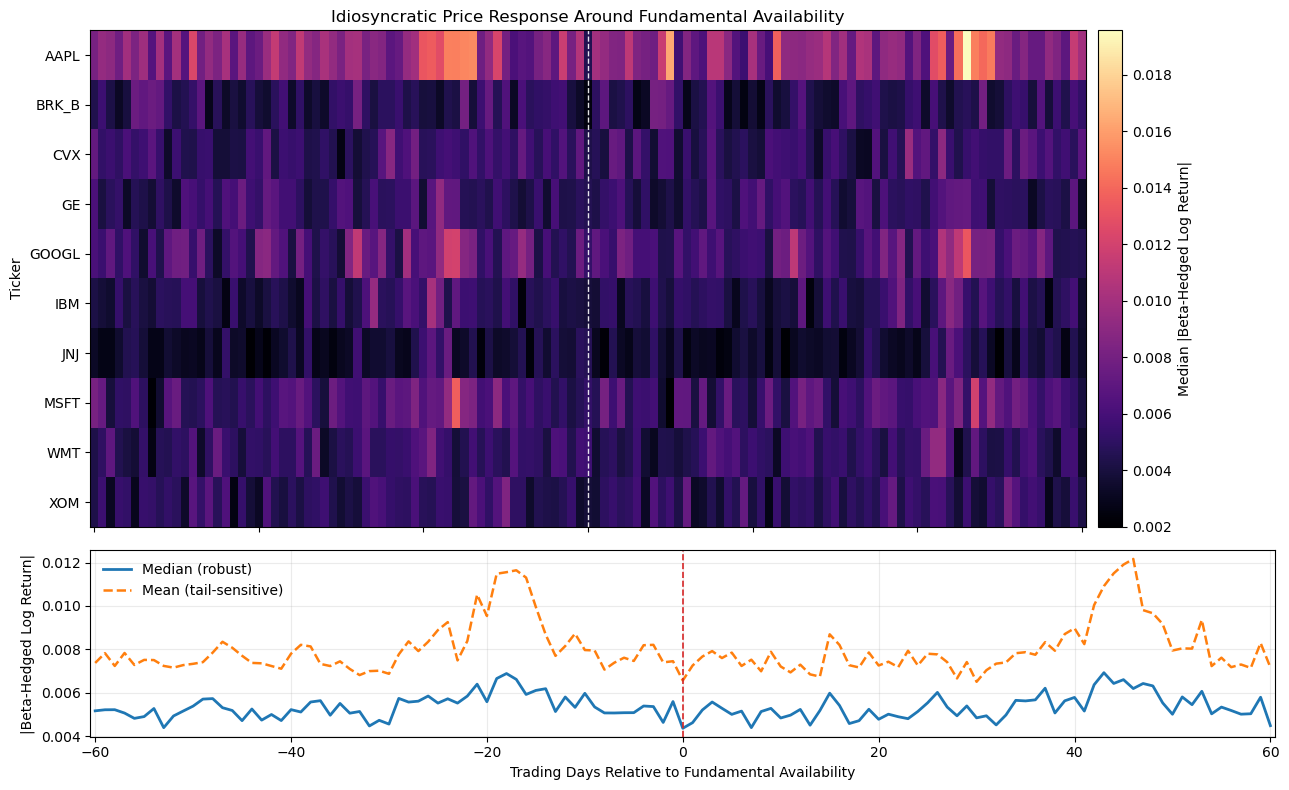

In [31]:
idio_diag = compute_event_intensity_diagnostics(
    mode="beta_hedged",
    prices_df=prices_adj,
    fundamentals_df=fundamentals,
    window=EVENT_WINDOW,
    beta_df=beta_df,
)

idio_heatmap = idio_diag["heatmap_df"]
idio_baseline_median = idio_diag["baseline_median"]
idio_baseline_mean = idio_diag["baseline_mean"]
idio_event_panel = idio_diag["event_panel_df"]

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 8),
    gridspec_kw={"height_ratios": [3.2, 1.2]},
    sharex=True,
)

im = ax1.imshow(
    idio_heatmap.values.astype(float),
    aspect="auto",
    cmap="magma",
    interpolation="nearest",
    extent=[-EVENT_WINDOW - 0.5, EVENT_WINDOW + 0.5, len(idio_heatmap.index) - 0.5, -0.5],
)
ax1.set_title(idio_diag["figure_title"])
ax1.set_ylabel("Ticker")
ax1.set_yticks(range(len(idio_heatmap.index)))
ax1.set_yticklabels(idio_heatmap.index.tolist())
ax1.axvline(0, color="white", linestyle="--", linewidth=1, alpha=0.9)
cb = fig.colorbar(im, ax=ax1, pad=0.01)
cb.set_label(idio_diag["colorbar_label"])

x = idio_baseline_median.index.values
ax2.plot(x, idio_baseline_median.values, color="tab:blue", linewidth=2, linestyle="-", label="Median (robust)")
ax2.plot(x, idio_baseline_mean.reindex(idio_baseline_median.index).values, color="tab:orange", linewidth=1.8, linestyle="--", label="Mean (tail-sensitive)")
ax2.axvline(0, color="tab:red", linestyle="--", linewidth=1.2)
ax2.set_xlabel("Trading Days Relative to Fundamental Availability")
ax2.set_ylabel(idio_diag["y_label"])
ax2.grid(alpha=0.25)
ax2.legend(loc="best", frameon=False)

fig.tight_layout()
fig5_path = FIG_DIR / "lstm_fundamental_timing_vs_idiosyncratic_return.png"
fig.savefig(fig5_path, dpi=150)
plt.show()


This figure repeats the event-time view after removing contemporaneous market exposure via beta hedging. The remaining intensity captures firm-specific movement not explained by the broad market component. If diffuse structure persists after hedging, then the timing behavior is less likely to be purely a market-volatility artifact. That makes the resulting signal design more economically interpretable at the issuer level. The median-versus-mean overlay again separates robust central tendency from tail-sensitive behavior. As with Figure 4, this is a diagnostic motivation figure rather than a performance claim.


## Preliminary Modeling Framework: LSTM
We use an LSTM specification because it can store and update information through gated memory cells instead of forcing one fixed lag structure. The forget, input, and output gates let the model adaptively weight recent versus older observations depending on current sequence state. This flexibility is useful when financial responses to fundamentals are nonlinear and vary across market regimes. 

In this draft, each sample is a rolling sequence of engineered daily features for one ticker over a fixed lookback window. The feature tensor includes price-based dynamics, point-in-time fundamentals, and market-exposure controls. The target is the next-day log return for that ticker. 

The training objective for the eventual model stage is a supervised loss such as mean squared error on one-step-ahead predictions. We do not tune architecture depth, hidden width, or regularization in this draft. We also do not run training diagnostics or compare benchmark models here. 

The purpose at this stage is to ensure the data representation is technically correct and economically interpretable before model fitting. At the draft stage, we restrict ourselves to dataset construction and model specification. No training diagnostics, hyperparameter tuning, or performance evaluation are presented.

In [32]:
# Tensor construction only (no training in draft)
# Uses the 10-feature list (incl. atm_iv_30d) and panel_with_opts.
# Fall back to original panel + 9 features if IV join hasn't run yet.
if "atm_iv_30d" in panel_with_opts.columns:
    _tensor_panel = panel_with_opts
    _tensor_features = model_feature_cols_with_iv   # defined in options export cell
else:
    _tensor_panel = panel
    _tensor_features = [
        "adj_close", "volume", "tot_debt_tot_equity", "ret_equity",
        "profit_margin", "book_val_per_share", "diluted_net_eps", "price_to_book", "beta_252d",
    ]

_tensor_features = [c for c in _tensor_features if c in _tensor_panel.columns]
print(f"Building tensors with {len(_tensor_features)} features: {_tensor_features}")

tensors = build_lstm_tensors(
    panel_df=_tensor_panel,
    feature_cols=_tensor_features,
    target_col="target_next_log_ret",
    lookback=LOOKBACK,
    split_col="split",
)

for split_name in ["train", "dev", "test"]:
    x_split, y_split = tensors[split_name]
    print(f"{split_name}: X{tuple(x_split.shape)} y{tuple(y_split.shape)}")


Building tensors with 10 features: ['adj_close', 'volume', 'tot_debt_tot_equity', 'ret_equity', 'profit_margin', 'book_val_per_share', 'diluted_net_eps', 'price_to_book', 'beta_252d', 'atm_iv_30d']
train: X(9223, 20, 10) y(9223,)
dev: X(1840, 20, 10) y(1840,)
test: X(1924, 20, 10) y(1924,)


## Export Processed Artifacts

In [33]:
panel_out = panel.copy().sort_values(["ticker", "date"]).reset_index(drop=True)

panel_csv = OUTPUT_DIR / "lstm_feature_panel_2006_2013.csv"
panel_out.to_csv(panel_csv, index=False)

panel_parquet = OUTPUT_DIR / "lstm_feature_panel_2006_2013.parquet"
try:
    panel_out.to_parquet(panel_parquet, index=False)
except Exception:
    pass

universe_csv = OUTPUT_DIR / "lstm_static_top10_universe_2012_12_31.csv"
top10.to_csv(universe_csv, index=False)

qa_files = [
    FIG_DIR / "lstm_top10_adjusted_price_paths.png",
    FIG_DIR / "lstm_feature_missingness_heatmap.png",
    FIG_DIR / "lstm_forward_fill_no_lookahead_example.png",
    FIG_DIR / "lstm_fundamental_timing_vs_return_response.png",
    FIG_DIR / "lstm_fundamental_timing_vs_idiosyncratic_return.png",
]

for file_path in qa_files:
    if not file_path.exists():
        raise FileNotFoundError(f"Missing expected figure: {file_path}")

export_manifest = {
    "panel_csv": str(panel_csv),
    "panel_parquet": str(panel_parquet),
    "universe_csv": str(universe_csv),
    "figures": [str(p) for p in qa_files],
    "rows": len(panel_out),
    "tickers": sorted(panel_out["ticker"].dropna().unique().tolist()),
}
export_manifest


{'panel_csv': 'C:\\Users\\vidhi\\OneDrive\\Desktop\\FINM\\Winter\\Quant Trading Strat\\Git\\team_t\\data\\lstm_draft\\processed\\lstm_feature_panel_2006_2013.csv',
 'panel_parquet': 'C:\\Users\\vidhi\\OneDrive\\Desktop\\FINM\\Winter\\Quant Trading Strat\\Git\\team_t\\data\\lstm_draft\\processed\\lstm_feature_panel_2006_2013.parquet',
 'universe_csv': 'C:\\Users\\vidhi\\OneDrive\\Desktop\\FINM\\Winter\\Quant Trading Strat\\Git\\team_t\\data\\lstm_draft\\processed\\lstm_static_top10_universe_2012_12_31.csv',
 'figures': ['C:\\Users\\vidhi\\OneDrive\\Desktop\\FINM\\Winter\\Quant Trading Strat\\Git\\team_t\\docs\\figures\\lstm_top10_adjusted_price_paths.png',
  'C:\\Users\\vidhi\\OneDrive\\Desktop\\FINM\\Winter\\Quant Trading Strat\\Git\\team_t\\docs\\figures\\lstm_feature_missingness_heatmap.png',
  'C:\\Users\\vidhi\\OneDrive\\Desktop\\FINM\\Winter\\Quant Trading Strat\\Git\\team_t\\docs\\figures\\lstm_forward_fill_no_lookahead_example.png',
  'C:\\Users\\vidhi\\OneDrive\\Desktop\\FINM\\